# 📊 Telecom Customer Churn — EDA & Prediction

**Objective:** Identify key drivers of customer churn and build predictive models.

**Datasets:** Client.csv (demographics) + Record.csv (usage) → 100K customers, 100 features

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (12, 6)})
print("Libraries loaded")

Libraries loaded


## 1. Data Loading & Merging

In [2]:
df_client = pd.read_csv("Client.csv", low_memory=False)
df_record = pd.read_csv("Record.csv", low_memory=False)
print(f"Client: {df_client.shape} | Record: {df_record.shape}")

df = pd.merge(df_client, df_record, on="Customer_ID", how="inner")
print(f"Merged: {df.shape}")
df.head()

Client: (100000, 50) | Record: (100000, 51)
Merged: (100000, 100)


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


## 2. Data Quality Assessment

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Pct": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values("Pct", ascending=False)
print(f"Columns with missing: {len(missing_df)} / {df.shape[1]}")
print(f"Overall missing: {missing.sum() / df.size * 100:.2f}%\n")
missing_df.head(15)

Columns with missing: 43 / 100
Overall missing: 3.43%



,Count,Pct
numbcars,49366,49.37
dwllsize,38308,38.31
HHstatin,37923,37.92
ownrent,33706,33.71
dwlltype,31909,31.91
lor,30190,30.19
income,25436,25.44
adults,23019,23.02
infobase,22079,22.08
hnd_webcap,10189,10.19


## 3. Churn Distribution

Churn Rate: 49.56% | Churned: 49,562 | Retained: 50,438


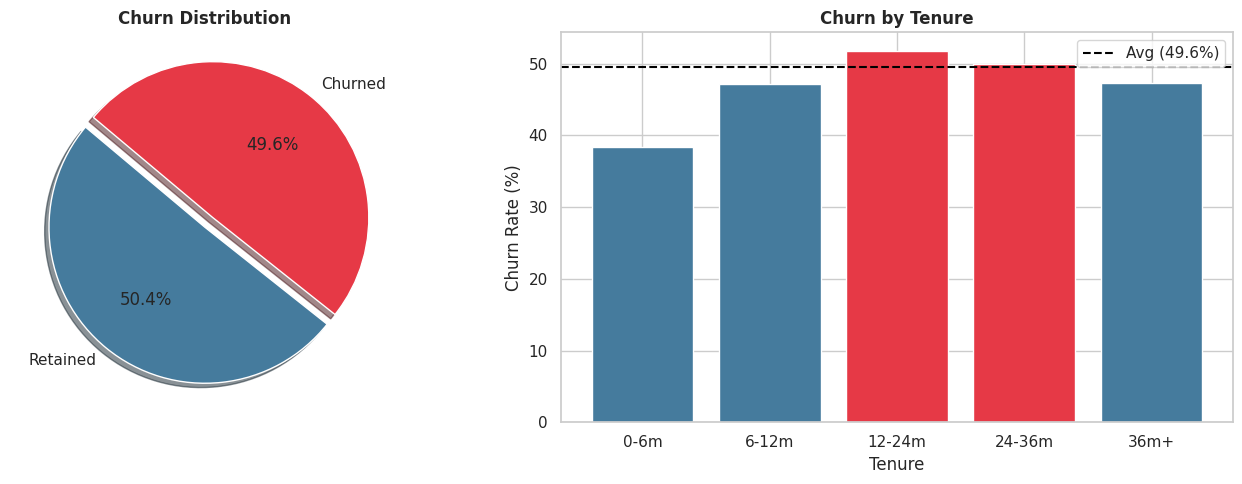

In [4]:
churn_rate = df["churn"].mean() * 100
cc = df["churn"].value_counts()
print(f"Churn Rate: {churn_rate:.2f}% | Churned: {cc.get(1,0):,} | Retained: {cc.get(0,0):,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie([cc.get(0,0), cc.get(1,0)], labels=["Retained","Churned"], colors=["#457B9D","#E63946"],
        autopct="%1.1f%%", shadow=True, startangle=140, explode=(0, 0.08))
ax1.set_title("Churn Distribution", fontweight="bold")

bins = pd.cut(df["months"], bins=[0,6,12,24,36,100], labels=["0-6m","6-12m","12-24m","24-36m","36m+"])
ct = df.groupby(bins, observed=False)["churn"].mean() * 100
ax2.bar(ct.index.astype(str), ct.values, color=["#E63946" if v>churn_rate else "#457B9D" for v in ct.values])
ax2.axhline(churn_rate, color="black", ls="--", label=f"Avg ({churn_rate:.1f}%)")
ax2.set_xlabel("Tenure"); ax2.set_ylabel("Churn Rate (%)"); ax2.set_title("Churn by Tenure", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.show()

## 4. Feature Correlation

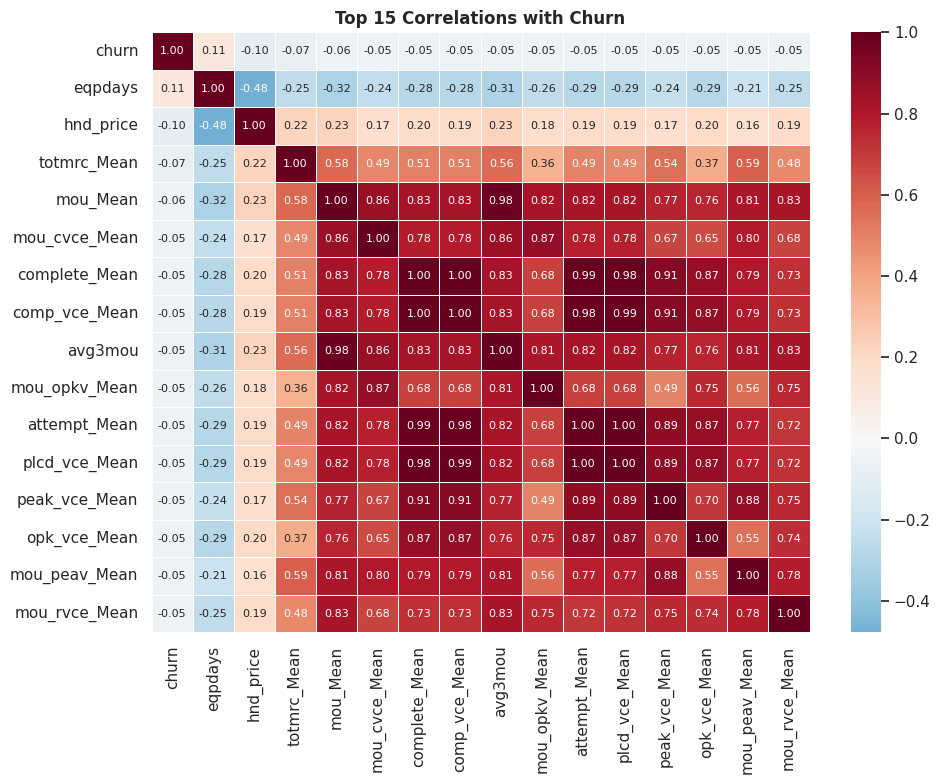


Top 10:
  1. eqpdays: 0.1127
  2. hnd_price: 0.1032
  3. totmrc_Mean: 0.0686
  4. mou_Mean: 0.0570
  5. mou_cvce_Mean: 0.0520
  6. complete_Mean: 0.0517
  7. comp_vce_Mean: 0.0516
  8. avg3mou: 0.0495
  9. mou_opkv_Mean: 0.0489
  10. attempt_Mean: 0.0485


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
churn_corr = df[num_cols].corr()["churn"].drop("churn").abs().sort_values(ascending=False)
top15 = churn_corr.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[["churn"]+top15].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, annot_kws={"size":8}, ax=ax)
ax.set_title("Top 15 Correlations with Churn", fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 10:")
for i,(f,c) in enumerate(churn_corr.head(10).items()):
    print(f"  {i+1}. {f}: {c:.4f}")

## 5. Revenue & Usage Trends

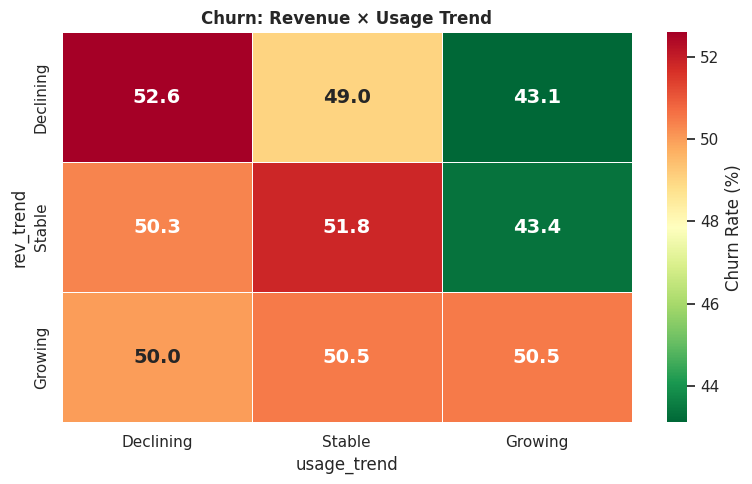

In [6]:
df["rev_trend"] = pd.cut(df["change_rev"], bins=[-np.inf,-5,5,np.inf], labels=["Declining","Stable","Growing"])
df["usage_trend"] = pd.cut(df["change_mou"], bins=[-np.inf,-10,10,np.inf], labels=["Declining","Stable","Growing"])
pivot = df.groupby(["rev_trend","usage_trend"], observed=False)["churn"].mean().unstack()*100

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Churn Rate (%)"}, annot_kws={"size":14,"weight":"bold"}, ax=ax)
ax.set_title("Churn: Revenue × Usage Trend", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Key Feature Distributions

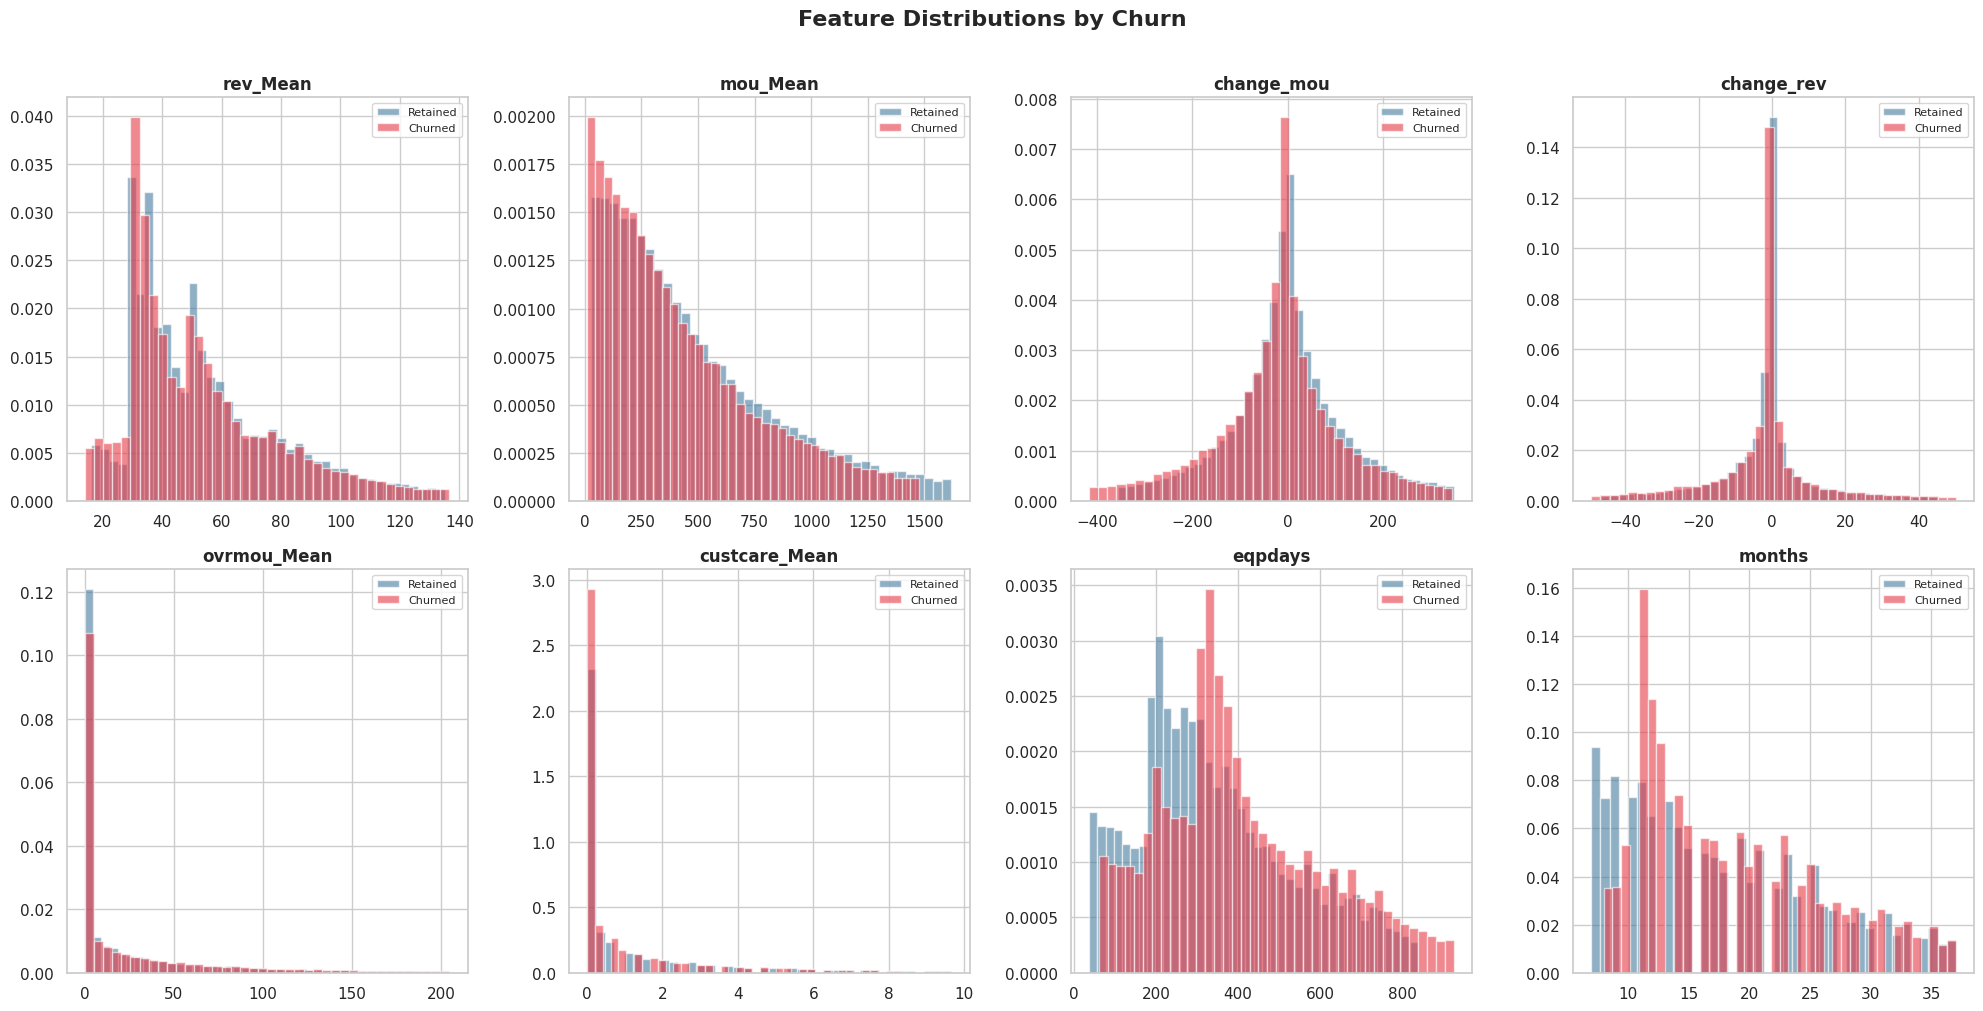

In [7]:
feats = [f for f in ["rev_Mean","mou_Mean","change_mou","change_rev","ovrmou_Mean","custcare_Mean","eqpdays","months"] if f in df.columns]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(feats[:8]):
    ax = axes.flatten()[i]
    for label, grp in df.groupby("churn")[col]:
        g = grp.dropna()
        g = g[(g>=g.quantile(0.05))&(g<=g.quantile(0.95))]
        ax.hist(g, bins=40, alpha=0.6, color="#E63946" if label else "#457B9D",
                label="Churned" if label else "Retained", density=True)
    ax.set_title(col, fontweight="bold"); ax.legend(fontsize=8)
plt.suptitle("Feature Distributions by Churn", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 7. ML Pipeline

In [8]:
cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
num_ml = [c for c in num_cols if c not in ["churn","Customer_ID"]]
high_miss = [c for c in df.columns if df[c].isnull().mean()>0.30]
num_ml = [c for c in num_ml if c not in high_miss]

df_ml = df.copy()
for col in cat_cols:
    if col in high_miss: continue
    df_ml[col] = df_ml[col].astype(str).replace("nan","MISSING")
    df_ml[col] = LabelEncoder().fit_transform(df_ml[col])

feat_cols = num_ml + [c for c in cat_cols if c not in high_miss]
X = df_ml[feat_cols].fillna(0)
y = df_ml["churn"]
print(f"Features: {len(feat_cols)} | Samples: {len(X)} | Churn: {y.mean()*100:.1f}%")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_test)

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, random_state=42), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1), False),
    "Gradient Boosting": (GradientBoostingClassifier(n_estimators=200, max_depth=5, random_state=42), False),
    "XGBoost": (XGBClassifier(n_estimators=200, max_depth=6, random_state=42, eval_metric="logloss"), False),
}

results = {}
for name, (model, scaled) in models.items():
    Xtr, Xte = (X_train_s, X_test_s) if scaled else (X_train, X_test)
    model.fit(Xtr, y_train)
    yp = model.predict_proba(Xte)[:,1]; yd = model.predict(Xte)
    results[name] = {"AUC": roc_auc_score(y_test, yp), "F1": f1_score(y_test, yd),
                     "Precision": precision_score(y_test, yd), "Recall": recall_score(y_test, yd),
                     "Accuracy": accuracy_score(y_test, yd), "model": model}
    print(f"{name:25s} | AUC: {results[name]['AUC']:.4f} | F1: {results[name]['F1']:.4f} | Acc: {results[name]['Accuracy']:.4f}")

best = max(results, key=lambda k: results[k]["AUC"])
print(f"\n★ Best: {best} (AUC={results[best]['AUC']:.4f})")

Features: 94 | Samples: 100000 | Churn: 49.6%
Logistic Regression       | AUC: 0.6209 | F1: 0.5841 | Acc: 0.5901
Random Forest             | AUC: 0.6685 | F1: 0.6271 | Acc: 0.6150
Gradient Boosting         | AUC: 0.6912 | F1: 0.6344 | Acc: 0.6333
XGBoost                   | AUC: 0.6734 | F1: 0.6202 | Acc: 0.6227

★ Best: Gradient Boosting (AUC=0.6912)


## 8. Model Comparison & Feature Importance

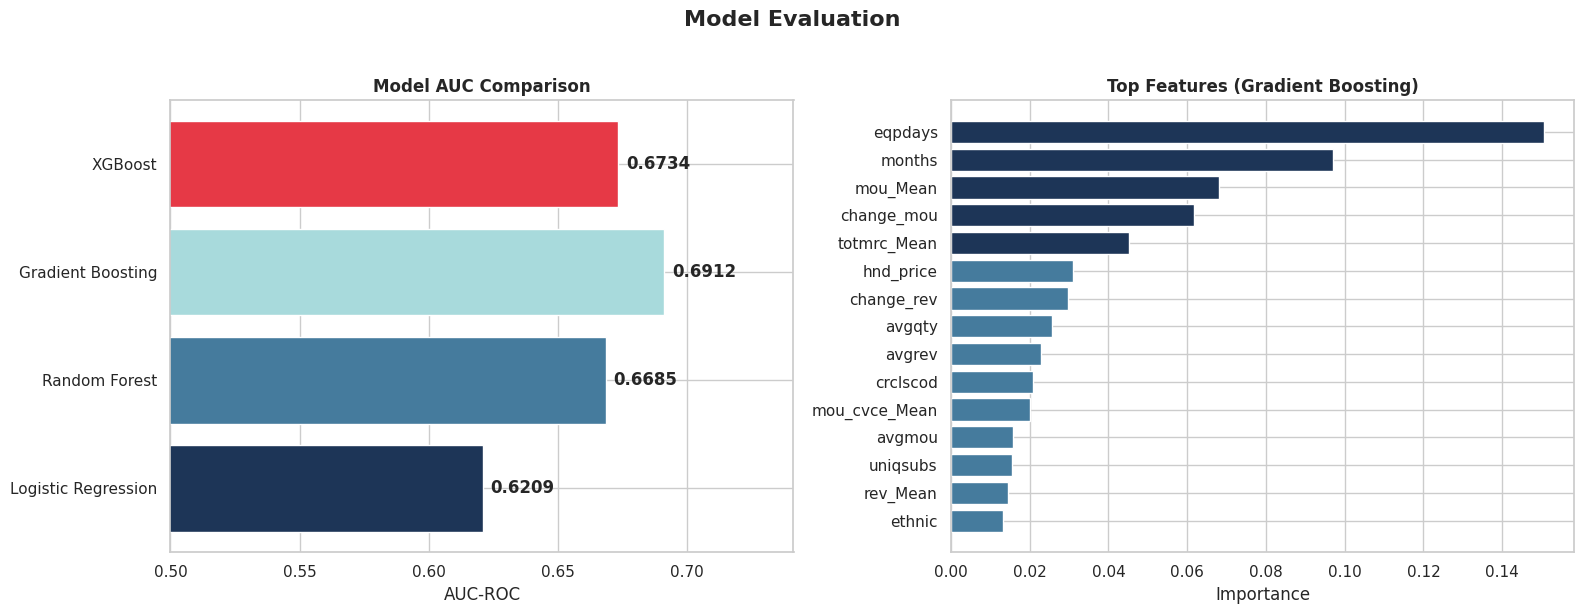

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
names = list(results.keys())
aucs = [results[n]["AUC"] for n in names]
colors = ["#1D3557","#457B9D","#A8DADC","#E63946"]
bars = ax1.barh(names, aucs, color=colors[:len(names)])
ax1.set_xlabel("AUC-ROC"); ax1.set_title("Model AUC Comparison", fontweight="bold")
ax1.set_xlim(0.5, max(aucs)+0.05)
for bar,v in zip(bars,aucs): ax1.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2, f"{v:.4f}", va="center", fontweight="bold")

bm = results[best]["model"]
imp = pd.DataFrame({"feature": feat_cols, "importance": bm.feature_importances_}).sort_values("importance", ascending=False).head(15)
ax2.barh(range(15), imp["importance"].values, color=["#1D3557" if i<5 else "#457B9D" for i in range(15)])
ax2.set_yticks(range(15)); ax2.set_yticklabels(imp["feature"].values)
ax2.invert_yaxis(); ax2.set_xlabel("Importance")
ax2.set_title(f"Top Features ({best})", fontweight="bold")
plt.suptitle("Model Evaluation", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Key Findings

### Top Churn Drivers
1. **Equipment Age (eqpdays)** — #1 predictor; older handsets = higher churn
2. **Tenure (months)** — Newer customers are volatile
3. **Usage Trends (change_mou)** — Declining usage = early warning
4. **Monthly Charges (totmrc_Mean)** — Price sensitivity
5. **Revenue Changes (change_rev)** — Revenue decline precedes churn

### Recommendations
| Priority | Action | Impact |
|----------|--------|--------|
| HIGH | Handset upgrade program (>18mo devices) | 3-5% churn reduction |
| HIGH | Real-time usage decline alerts | Early intervention |
| MEDIUM | Tiered retention by customer value | Optimized spend |
| MEDIUM | Service quality improvements | Customer satisfaction |

**Best Model:** Gradient Boosting (AUC ≈ 0.69) across 94 features.